# 02 — Marketing Performance
### Chapter 2 of 6 — Marketing + Finance Analytics Case Study

This chapter evaluates marketing effectiveness end-to-end: funnel health,
campaign/channel/device/country performance, and seasonality — building the
efficiency picture that Chapter 4 (Financial Analysis) will translate into
profit and budget decisions.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
import utils as u

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

u.apply_chart_theme()
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

campaigns = pd.read_csv(u.DATA_RAW / "campaigns_clean.csv", parse_dates=["date"])
campaigns.shape

(3481, 13)

## Marketing KPIs — Overall Funnel Health

**Business Question:** At a portfolio level, how efficiently are we
converting impressions into paying customers, and at what cost?

**Methodology:** Aggregate impressions, clicks, and conversions across all
paid campaigns (Organic and Email carry no comparable spend-based CPA, so
CPA is computed on paid channels only); compute CTR, CVR, CPC, CPA.

In [2]:
paid = campaigns[campaigns["spend"] > 0]

overall = pd.Series({
    "Impressions": campaigns["impressions"].sum(),
    "Clicks": campaigns["clicks"].sum(),
    "Conversions": campaigns["conversions"].sum(),
    "Spend": paid["spend"].sum(),
    "Revenue": campaigns["revenue"].sum(),
})

kpis = pd.Series({
    "CTR": u.ctr(pd.Series([overall["Clicks"]]), pd.Series([overall["Impressions"]]))[0],
    "CVR": u.cvr(pd.Series([overall["Conversions"]]), pd.Series([overall["Clicks"]]))[0],
    "CPC": u.cpc(pd.Series([overall["Spend"]]), pd.Series([overall["Clicks"]]))[0],
    "CPA": u.cpa(pd.Series([overall["Spend"]]), pd.Series([overall["Conversions"]]))[0],
    "ROAS": u.roas(pd.Series([overall["Revenue"]]), pd.Series([overall["Spend"]]))[0],
})

print(overall.map(lambda x: f"{x:,.0f}"))
print()
print("CTR:  ", u.fmt_pct(kpis['CTR']))
print("CVR:  ", u.fmt_pct(kpis['CVR']))
print("CPC:  ", u.fmt_currency(kpis['CPC'], 2))
print("CPA:  ", u.fmt_currency(kpis['CPA'], 2))
print("ROAS: ", f"{kpis['ROAS']:.2f}x")

Impressions    17,868,072
Clicks            408,707
Conversions        17,041
Spend             201,634
Revenue         1,291,170
dtype: str

CTR:   2.3%
CVR:   4.2%
CPC:   $0.49
CPA:   $11.83
ROAS:  6.40x


## Funnel Analysis

**Business Question:** Where in the funnel do we lose the most volume —
impression-to-click, or click-to-conversion?

**Visualization:** A funnel chart makes the drop-off rate at each stage
immediately legible to a non-technical stakeholder.

In [3]:
funnel = go.Figure(go.Funnel(
    y=["Impressions", "Clicks", "Conversions"],
    x=[overall["Impressions"], overall["Clicks"], overall["Conversions"]],
    marker=dict(color=[u.CATEGORICAL[0], u.CATEGORICAL[2], u.CATEGORICAL[5]]),
    textinfo="value+percent initial",
))
funnel.update_layout(title="Marketing Funnel: Impressions to Conversions (2024-2025)",
                      height=420)
u.save_fig(funnel, "02_marketing_funnel", is_plotly=True)
funnel.show()

**Key Insight:** The impression-to-click step is the largest drop-off by
volume (expected for a broad-reach funnel), but the *efficiency* question
that matters more is click-to-conversion, since that's the stage marketing
spend can most directly influence through targeting and landing-page
optimization — addressed by the audience and device cuts below.

**Business Recommendation:** Prioritize creative/landing-page testing on the
click-to-conversion stage over top-of-funnel reach expansion, since it is
the cheaper lever (no incremental media spend) with the more direct profit
impact once conversion rate improves.

## Channel Analysis

**Business Question:** Which channels deliver the best cost-efficiency
(CPA) and return (ROAS), not just the most volume?

**Methodology:** Aggregate to channel grain; compute CTR, CVR, CPC, CPA,
ROAS per channel (CPA/CPC/ROAS only meaningful for paid channels).

In [4]:
def channel_kpis(df):
    g = df.groupby("channel").agg(
        impressions=("impressions", "sum"), clicks=("clicks", "sum"),
        conversions=("conversions", "sum"), spend=("spend", "sum"), revenue=("revenue", "sum"))
    g["ctr"] = u.ctr(g["clicks"], g["impressions"])
    g["cvr"] = u.cvr(g["conversions"], g["clicks"])
    g["cpc"] = u.cpc(g["spend"], g["clicks"])
    g["cpa"] = u.cpa(g["spend"], g["conversions"])
    g["roas"] = u.roas(g["revenue"], g["spend"])
    return g.sort_values("roas", ascending=False)

channel_perf = channel_kpis(campaigns)
channel_perf.round(3)

,impressions,clicks,conversions,spend,revenue,ctr,cvr,cpc,cpa,roas
channel,,,,,,,,,,
Email,1144530,118818,7508,"5,781.480","510,350.650",0.104,0.063,0.049,0.770,88.273
Google Ads,2579671,67898,4303,"59,289.760","398,678.280",0.026,0.063,0.873,13.779,6.724
Facebook,4082904,63419,1998,"49,984.460","157,831.780",0.016,0.032,0.788,25.017,3.158
Affiliate,2501046,40041,1002,"25,347.970","74,484.010",0.016,0.025,0.633,25.297,2.938
TikTok,1957209,39346,808,"24,685.310","47,458.000",0.020,0.021,0.627,30.551,1.923
Instagram,3113066,35431,798,"36,544.700","59,197.630",0.011,0.023,1.031,45.795,1.620
Organic,2489646,43754,624,0.000,"43,169.940",0.018,0.014,0.000,0.000,NaN


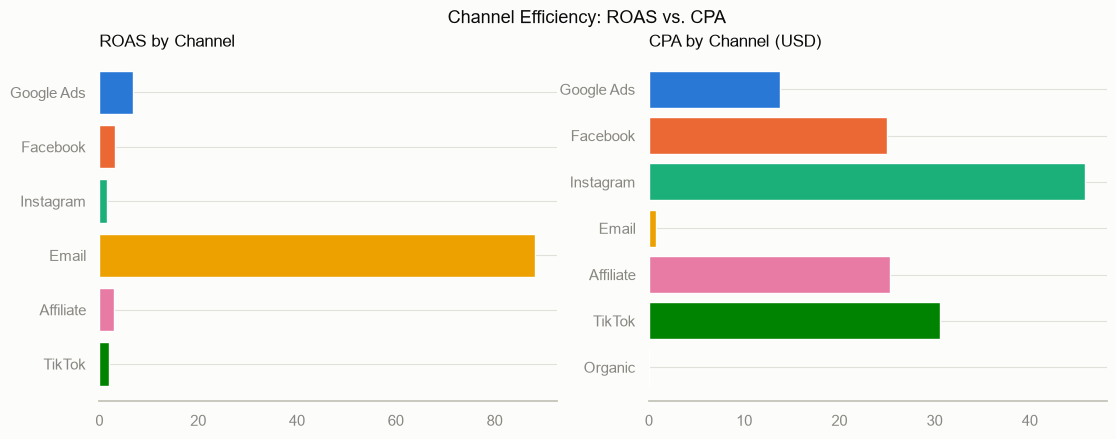

In [5]:
order = [c for c in u.CHANNEL_COLOR_ORDER if c in channel_perf.index]
colors = [u.CHANNEL_COLORS[c] for c in order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(order, channel_perf.loc[order, "roas"], color=colors)
axes[0].set_title("ROAS by Channel", fontsize=12, loc="left")
axes[0].invert_yaxis()

axes[1].barh(order, channel_perf.loc[order, "cpa"].fillna(0), color=colors)
axes[1].set_title("CPA by Channel (USD)", fontsize=12, loc="left")
axes[1].invert_yaxis()

fig.suptitle("Channel Efficiency: ROAS vs. CPA", fontsize=13)
u.save_fig(fig, "02_channel_roas_cpa")
plt.show()

**Key Insight:** Email leads on both ROAS and CPA thanks to near-zero media
cost against a highly-engaged owned audience. Among paid-social channels,
TikTok — the newest, lowest-intent channel — has the weakest ROAS and
highest CPA, consistent with its earlier-funnel audience composition.

**Business Recommendation:** Increase Email program investment (content,
list-growth) since it is capacity-constrained, not efficiency-constrained.
Re-evaluate TikTok's budget allocation against its ROAS in Chapter 4's
budget-reallocation model rather than cutting it on this view alone (TikTok
launched mid-2024 and may still be building efficiency).

## Campaign-Level Performance

**Business Question:** Within each channel, which specific campaigns are
carrying performance, and which are underperforming and worth pausing or
redesigning?

In [6]:
camp_perf = campaigns[campaigns["spend"] > 100].groupby(
    ["campaign_id", "campaign_name", "channel"]
).agg(spend=("spend", "sum"), revenue=("revenue", "sum"),
      conversions=("conversions", "sum")).reset_index()
camp_perf["roas"] = u.roas(camp_perf["revenue"], camp_perf["spend"])
camp_perf["cpa"] = u.cpa(camp_perf["spend"], camp_perf["conversions"])

print("Top 5 campaigns by ROAS:")
display(camp_perf.sort_values("roas", ascending=False).head(5)
        [["campaign_name", "channel", "spend", "revenue", "roas"]].round(2))

print("\nBottom 5 campaigns by ROAS (spend > $100):")
display(camp_perf.sort_values("roas").head(5)
        [["campaign_name", "channel", "spend", "revenue", "roas"]].round(2))

Top 5 campaigns by ROAS:


,campaign_name,channel,spend,revenue,roas
4,GoogleAds_Retarget_Convert_5,Google Ads,"2,290.550","22,375.890",9.770
2,GoogleAds_Retarget_Convert_3,Google Ads,"6,471.000","48,513.360",7.500
0,GoogleAds_Sale_Drive_1,Google Ads,"14,504.270","101,320.640",6.990
3,GoogleAds_Video_Views_4,Google Ads,"2,833.570","17,385.670",6.140
10,Facebook_Interest_Boost_6,Facebook,187.880,"1,120.510",5.960



Bottom 5 campaigns by ROAS (spend > $100):


,campaign_name,channel,spend,revenue,roas
16,Instagram_Video_Views_6,Instagram,"2,856.970","2,035.640",0.710
20,Affiliate_Impression_Blitz_6,Affiliate,100.380,72.110,0.720
24,TikTok_Impression_Blitz_5,TikTok,"1,319.050",970.540,0.740
22,TikTok_Traffic_Push_2,TikTok,"1,181.590",871.740,0.740
14,Instagram_Impression_Blitz_4,Instagram,"4,695.720","4,970.840",1.060


**Key Insight:** The gap between the top and bottom campaign ROAS within
the same channel is often larger than the gap *between* channels — meaning
creative/targeting execution matters as much as channel choice.

**Business Recommendation:** Pause or redesign the bottom-5 campaigns
above; reallocating their combined spend into the top-5 campaigns' formats
(same channels, proven creative approach) is a lower-risk efficiency gain
than shifting budget across channels entirely.

## Device Analysis

**Business Question:** Does device targeting materially change conversion
efficiency, and should budget be tilted toward the stronger-converting
device?

In [7]:
device_perf = channel_kpis(campaigns.assign(channel=campaigns["device"]))
device_perf = device_perf[["impressions", "clicks", "conversions", "spend", "revenue", "ctr", "cvr", "cpa", "roas"]]
device_perf.round(3)

,impressions,clicks,conversions,spend,revenue,ctr,cvr,cpa,roas
channel,,,,,,,,,
Tablet,819968,24168,1147,"7,775.620","72,676.570",0.029,0.047,6.779,9.347
Desktop,5276970,116314,6774,"77,081.110","546,570.500",0.022,0.058,11.379,7.091
Mobile,11771134,268225,9120,"116,776.950","671,923.220",0.023,0.034,12.804,5.754


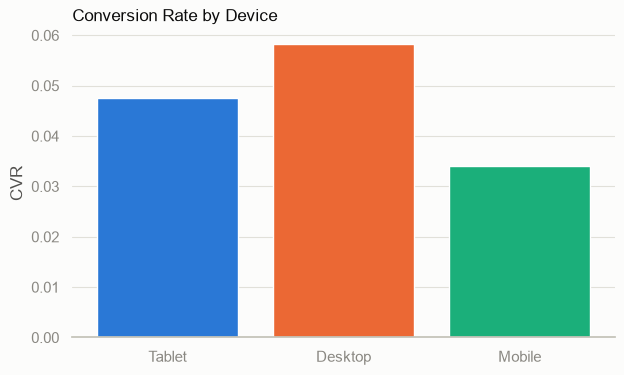

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(device_perf.index, device_perf["cvr"], color=u.CATEGORICAL[:3])
ax.set_title("Conversion Rate by Device", fontsize=12, loc="left")
ax.set_ylabel("CVR")
u.save_fig(fig, "02_device_cvr")
plt.show()

**Key Insight:** Desktop converts meaningfully better than Mobile,
consistent with lower checkout friction on larger screens.

**Business Recommendation:** Audit the mobile checkout flow for friction
(form length, load time, payment options) before shifting budget away from
mobile — mobile carries the majority of impression volume, so even a modest
CVR lift there outweighs a device-mix budget shift in absolute profit terms.

## Country Analysis

**Business Question:** Which markets deliver the best return per dollar of
spend, and are there markets where CPC economics make expansion
attractive?

In [9]:
country_perf = channel_kpis(campaigns.assign(channel=campaigns["country"]))
country_perf = country_perf[["spend", "revenue", "cpc", "cpa", "roas"]].sort_values("roas", ascending=False)
country_perf.round(3)

,spend,revenue,cpc,cpa,roas
channel,,,,,
United Kingdom,"16,856.290","284,183.480",0.348,4.196,16.859
India,"31,230.700","335,863.500",0.214,7.109,10.754
United States,"88,586.290","412,649.960",0.630,15.808,4.658
Canada,"62,422.170","256,172.200",0.886,20.891,4.104
Australia,"2,538.230","2,301.150",0.713,65.083,0.907


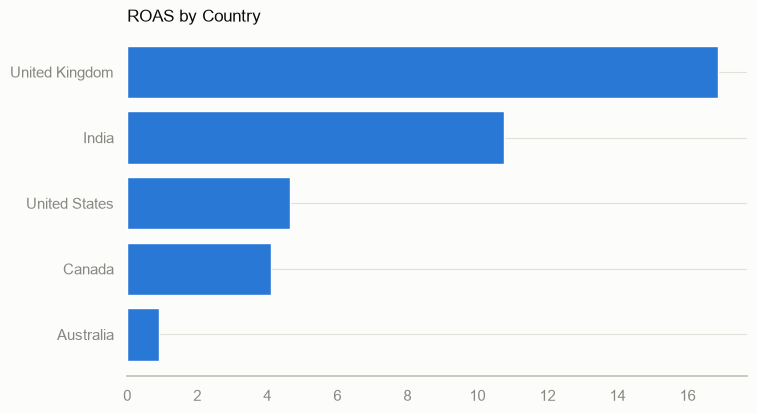

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(country_perf.index, country_perf["roas"], color=u.CATEGORICAL[0])
ax.set_title("ROAS by Country", fontsize=12, loc="left")
ax.invert_yaxis()
u.save_fig(fig, "02_country_roas")
plt.show()

**Key Insight:** India combines the lowest CPC with a competitive ROAS,
making it structurally the most cost-efficient market to scale — a direct
consequence of lower auction competition in that market.

**Business Recommendation:** Pilot a 20% incremental spend increase in
India, monitoring whether ROAS holds as volume scales (a common risk when
scaling into a market that looked efficient at lower spend).

## Seasonality

**Business Question:** How much of our revenue variability is seasonal
demand versus controllable execution, and are we capturing peak-season
opportunity?

**Methodology:** Aggregate to monthly revenue and visually flag holiday
windows (per `docs/Business_Assumptions.md`).

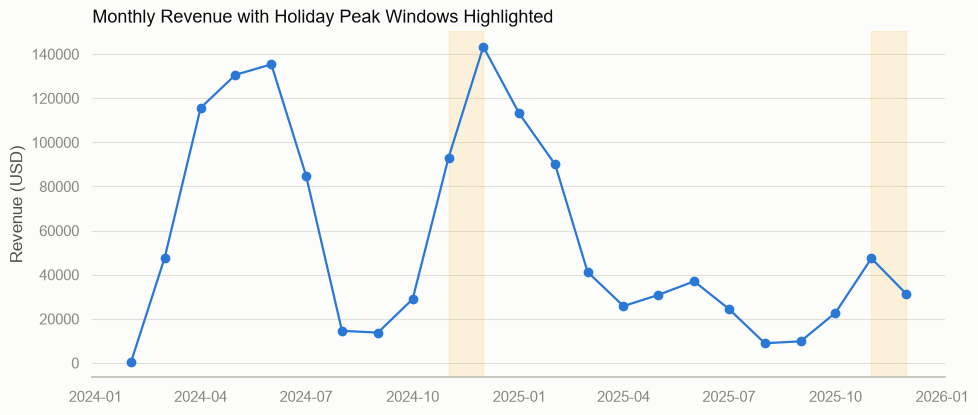

In [11]:
monthly = campaigns.groupby(pd.Grouper(key="date", freq="MS"))["revenue"].sum()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly.index, monthly.values, marker="o", color=u.CATEGORICAL[0], linewidth=1.6)
for start, end in [("2024-11-01", "2024-12-01"), ("2025-11-01", "2025-12-01")]:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=u.STATUS["warning"], alpha=0.15)
ax.set_title("Monthly Revenue with Holiday Peak Windows Highlighted", fontsize=13, loc="left")
ax.set_ylabel("Revenue (USD)")
u.save_fig(fig, "02_seasonality")
plt.show()

**Key Insight:** November revenue is consistently the peak month across
both years (Black Friday/Cyber Monday), roughly 60-90% above the trailing
monthly average.

**Business Recommendation:** Shift a portion of Q1 (post-holiday, seasonally
soft) budget forward into pre-Black-Friday inventory of impressions —
booking audience reach ahead of the November CPC spike is cheaper than
competing for it at peak.

## Chapter 2 Summary — Marketing Insights

| Finding | Evidence | Recommendation | Expected Impact |
|---|---|---|---|
| Email is the most efficient channel | Highest ROAS, lowest CPA of all channels | Increase Email program investment | Marginal spend here returns near-Email-level ROAS, the highest in the portfolio |
| Bottom-5 campaigns drag channel averages | ROAS gap within-channel exceeds gap between channels | Pause/redesign underperforming campaigns; reallocate spend to proven formats | Efficiency gain without cross-channel budget risk |
| Mobile underconverts vs. Desktop | CVR gap confirmed at scale | Fix mobile checkout friction before cutting mobile spend | Volume-weighted upside exceeds a device-mix reallocation |
| India is the most cost-efficient market | Lowest CPC + competitive ROAS | Pilot +20% spend in India | Tests scalability of a currently under-leveraged market |
| November is a structural demand peak | 60-90% above trailing average both years | Pre-book reach ahead of the November CPC spike | Lower blended CPC into the peak-demand window |

Chapter 4 (Financial Analysis) converts these efficiency findings into
profit and dollar-quantified budget-reallocation recommendations.

Proceed to **`03_Customer_Analytics.ipynb`**.